In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.preprocessing import StandardScaler

In [30]:
weather_df = pd.read_csv('../dataset/open-meteo_weather.csv')

radiation_df = pd.read_csv('../dataset/open-meteo_radiation.csv')


In [31]:
dataset_df = pd.merge(radiation_df, weather_df, on='time', how='inner')

In [32]:
dataset_df.head()

,time,shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²),temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%)
0,2019-01-01T00:00,48.2,0.0,48.2,0.0,368.1,16.7,82,13.6,15.4,0.1,97,53,20,0
1,2019-01-01T01:00,128.6,16.1,112.5,46.1,609.9,17.2,85,14.6,16.0,0.1,100,100,42,0
2,2019-01-01T02:00,104.4,4.5,99.9,9.0,794.1,17.1,80,13.6,15.8,0.1,100,100,47,0
3,2019-01-01T03:00,187.5,7.4,180.1,12.2,908.4,18.0,77,14.0,16.6,0.0,100,100,43,0
4,2019-01-01T04:00,194.4,13.2,181.2,19.9,944.8,17.9,78,14.0,16.6,0.1,100,100,42,0


In [33]:
dataset_df.columns

Index(['time', 'shortwave_radiation_instant (W/m²)',
       'direct_radiation_instant (W/m²)', 'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'dew_point_2m (°C)',
       'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)'],
      dtype='object')

In [34]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['month'] = dataset_df['time'].dt.month

# Pisahkan data berdasarkan musim
winter_df = dataset_df[dataset_df['month'].isin([1, 2, 3])]
spring_df = dataset_df[dataset_df['month'].isin([4, 5])]
summer_df = dataset_df[dataset_df['month'].isin([6, 7, 8, 9])]
autumn_df = dataset_df[dataset_df['month'].isin([10, 11])]
winter2_df = dataset_df[dataset_df['month'] == 12]

In [35]:
winter_df.set_index('time', inplace=True)
spring_df.set_index('time', inplace=True)
summer_df.set_index('time', inplace=True)
autumn_df.set_index('time', inplace=True)
winter2_df.set_index('time', inplace=True)

# Winter

In [36]:
winter_df.columns

Index(['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'dew_point_2m (°C)',
       'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'month'],
      dtype='object')

## Correlation

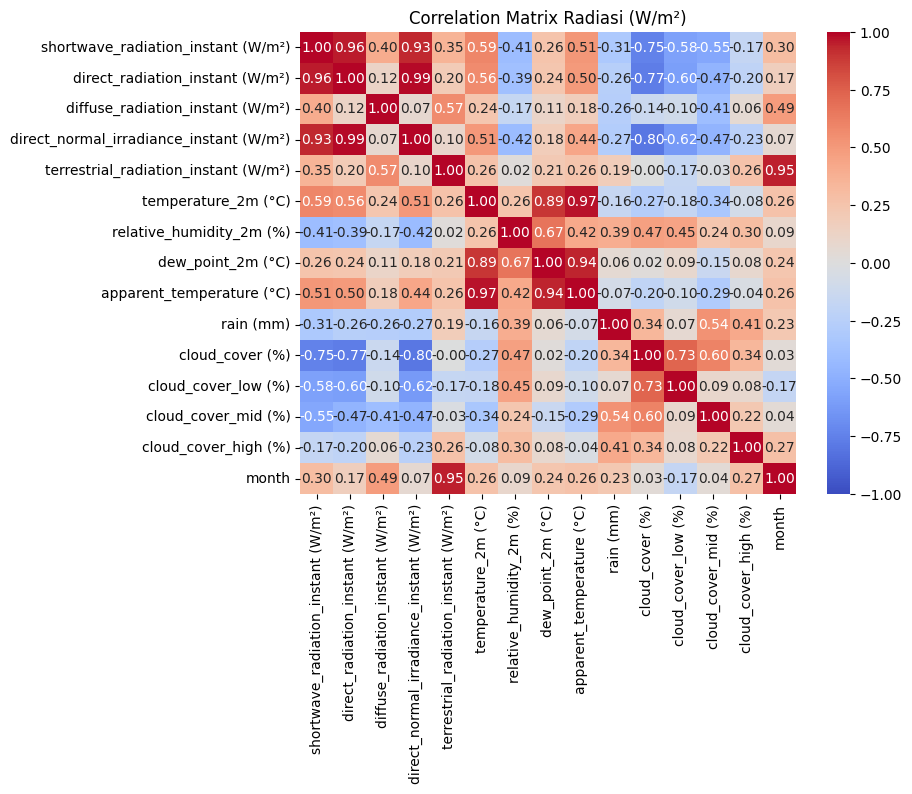

In [39]:
columns = ['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'dew_point_2m (°C)',
       'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'month']

daily_data = winter_df.resample('D').mean()
radiation_data = daily_data[columns]
corr_matrix = radiation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix Radiasi (W/m²)')
plt.show()